# P.7. Treasury Futures Options: Vol Regimes and Market Structure

## Setup

In [1]:
import pandas as pd
import numpy as np
import re
from pathlib import Path
from scipy.stats import norm
from scipy.optimize import minimize, brentq

import matplotlib.pyplot as plt
%matplotlib inline
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3


def resolve_project_data_path():
    base = Path('.').resolve()
    candidates = [
        base,
        base / 'data',
        base.parent / 'data',
        base / 'Project' / 'data',
        base.parent / 'Project' / 'data',
        Path.cwd() / 'data',
        Path.cwd().parent / 'data',
        Path.cwd() / 'Project' / 'data',
        Path.cwd().parent / 'Project' / 'data',
    ]
    if len(base.parents) > 1:
        candidates.append(base.parents[1] / 'Project' / 'data')

    for cand in candidates:
        if cand is None:
            continue
        if (cand / 'ty_option_surfaces_p7.xlsx').exists():
            return cand

    raise FileNotFoundError('Could not locate ty_option_surfaces_p7.xlsx in expected locations.')


DATA_PATH = resolve_project_data_path()


In [2]:
# Load TY option surfaces
VOLFILE = DATA_PATH / 'ty_option_surfaces_p7.xlsx'

contracts = {
    'M2025': 'CBT TY TY M2025',
    'H2026': 'CBT TY TY H2026',
    'M2026': 'CBT TY TY M2026',
}

surfs = {}
for key, sheet in contracts.items():
    surfs[key] = pd.read_excel(VOLFILE, sheet_name=sheet, index_col=0, parse_dates=True)

ty1 = pd.read_excel(VOLFILE, sheet_name='TY1 futures', index_col=0, parse_dates=True)
rates = pd.read_excel(VOLFILE, sheet_name='rates', index_col=0, parse_dates=True)


In [3]:
# Helper functions used throughout Q1–Q5

def nearest_date(index, target):
    target = pd.Timestamp(target)
    if target in index:
        return target
    loc = index.get_indexer([target], method='nearest')[0]
    return index[loc]


def delta_to_strike_black_future(F, delta_abs, sigma, T, side):
    q = norm.ppf(np.clip(delta_abs, 1e-6, 1 - 1e-6))
    if side.upper() == 'P':
        expo = q * sigma * np.sqrt(T) + 0.5 * sigma**2 * T
    else:
        expo = -q * sigma * np.sqrt(T) + 0.5 * sigma**2 * T
    return F * np.exp(expo)


def extract_smile_from_row(row, sides=('P', 'C')):
    F = float(row['Future Price'])
    T = float(row['Expiration Option'])
    records = []

    for col, val in row.items():
        m = re.match(r'^([PC])(\d+)dvol$', str(col))
        if m is None or pd.isna(val):
            continue

        side = m.group(1)
        if side not in sides:
            continue

        delta_abs = int(m.group(2)) / 100.0
        sigma = float(val)
        strike = delta_to_strike_black_future(F, delta_abs, sigma, T, side)

        records.append({
            'side': side,
            'delta_abs': delta_abs,
            'vol': sigma,
            'strike': strike,
        })

    smile = pd.DataFrame(records)
    if smile.empty:
        return smile

    smile = smile.sort_values('strike').reset_index(drop=True)
    smile['log_moneyness'] = np.log(smile['strike'] / F)
    smile['bp_from_atm'] = (smile['strike'] / F - 1.0) * 1e4
    return smile


def interpolate_atm_vol(smile, F):
    xs = smile['strike'].to_numpy()
    ys = smile['vol'].to_numpy()
    order = np.argsort(xs)
    return float(np.interp(F, xs[order], ys[order]))


def shape_metrics(smile, F):
    x = smile['log_moneyness'].to_numpy()
    y = smile['vol'].to_numpy()
    coef = np.polyfit(x, y, 2)

    order = np.argsort(x)
    x_sorted = x[order]
    y_sorted = y[order]

    return {
        'atm_vol_interp': interpolate_atm_vol(smile, F),
        'skew_coef': float(coef[1]),
        'curvature_coef': float(coef[0]),
        'left_minus_right_1pct': float(np.interp(-0.01, x_sorted, y_sorted) - np.interp(0.01, x_sorted, y_sorted)),
    }


def normalize_smile(strikes, vols, F, T):
    strikes = np.asarray(strikes, dtype=float)
    vols = np.asarray(vols, dtype=float)
    order = np.argsort(strikes)

    strikes = strikes[order]
    vols = vols[order]

    atm = float(np.interp(F, strikes, vols))
    x_norm = np.log(strikes / F) / (atm * np.sqrt(T))
    y_norm = vols / atm

    return pd.DataFrame({
        'strike': strikes,
        'vol': vols,
        'x_norm': x_norm,
        'vol_norm': y_norm,
        'atm_vol': atm,
    })


def sabr_vol_hagan(F, K, T, alpha, beta, rho, nu):
    F = np.asarray(F, dtype=float)
    K = np.asarray(K, dtype=float)

    one_minus_beta = 1.0 - beta
    FK = np.power(F * K, 0.5 * one_minus_beta)
    log_fk = np.log(F / K)

    z = (nu / alpha) * FK * log_fk
    sqrt_term = np.sqrt(np.maximum(1.0 - 2.0 * rho * z + z * z, 1e-14))
    x_z = np.log((sqrt_term + z - rho) / (1.0 - rho))

    with np.errstate(divide='ignore', invalid='ignore'):
        z_over_xz = z / x_z

    z_series = 1.0 - 0.5 * rho * z + ((2.0 - 3.0 * rho**2) / 12.0) * z**2
    z_over_xz = np.where(np.abs(z) < 1e-8, z_series, z_over_xz)

    log_fk2 = log_fk**2
    log_fk4 = log_fk2**2
    denom = FK * (1.0 + (one_minus_beta**2 / 24.0) * log_fk2 + (one_minus_beta**4 / 1920.0) * log_fk4)

    term1 = (one_minus_beta**2 / 24.0) * (alpha**2 / np.power(F * K, one_minus_beta))
    term2 = 0.25 * rho * beta * nu * alpha / FK
    term3 = ((2.0 - 3.0 * rho**2) / 24.0) * nu**2

    vol = (alpha / denom) * z_over_xz * (1.0 + (term1 + term2 + term3) * T)
    return np.asarray(vol, dtype=float)


def solve_alpha_from_atm(F, T, sigma_atm, beta, rho, nu):
    target = float(sigma_atm)

    def f(alpha):
        return float(sabr_vol_hagan(F, F, T, alpha, beta, rho, nu) - target)

    guess = max(target * (F ** (1.0 - beta)), 1e-4)
    low = max(1e-8, guess * 1e-3)
    high = max(1e-2, guess * 10.0)

    f_low = f(low)
    f_high = f(high)

    tries = 0
    while f_low * f_high > 0 and tries < 12:
        high *= 2.0
        f_high = f(high)
        tries += 1

    if f_low * f_high <= 0:
        return float(brentq(f, low, high, maxiter=300))

    grid = np.logspace(np.log10(low), np.log10(high), 250)
    errs = np.array([abs(f(a)) for a in grid])
    return float(grid[np.nanargmin(errs)])


def calibrate_sabr_smile(F, T, strikes, market_vols, atm_vol, beta=0.5, initial_guess=(0.5, -0.2), bounds=((1e-4, 3.0), (-0.999, 0.999))):
    strikes = np.asarray(strikes, dtype=float)
    market_vols = np.asarray(market_vols, dtype=float)

    valid = np.isfinite(strikes) & np.isfinite(market_vols)
    strikes = strikes[valid]
    market_vols = market_vols[valid]

    if len(strikes) < 5:
        raise ValueError('Need at least 5 valid smile points for SABR calibration.')

    def objective(x):
        nu, rho = x
        if nu <= 0 or abs(rho) >= 1:
            return 1e6

        alpha = solve_alpha_from_atm(F, T, atm_vol, beta, rho, nu)
        if not np.isfinite(alpha) or alpha <= 0:
            return 1e6

        model = sabr_vol_hagan(F, strikes, T, alpha, beta, rho, nu)
        if np.any(~np.isfinite(model)):
            return 1e6

        return float(np.mean((model - market_vols) ** 2))

    res = minimize(
        objective,
        x0=np.array(initial_guess, dtype=float),
        method='L-BFGS-B',
        bounds=bounds,
    )

    nu_hat, rho_hat = res.x
    alpha_hat = solve_alpha_from_atm(F, T, atm_vol, beta, rho_hat, nu_hat)
    model_vols = sabr_vol_hagan(F, strikes, T, alpha_hat, beta, rho_hat, nu_hat)
    residuals = model_vols - market_vols

    return {
        'alpha': float(alpha_hat),
        'nu': float(nu_hat),
        'rho': float(rho_hat),
        'rmse': float(np.sqrt(np.mean(residuals**2))),
        'sse': float(np.sum(residuals**2)),
        'success': bool(res.success),
        'message': str(res.message),
        'model_vols': model_vols,
        'market_vols': market_vols,
        'strikes': strikes,
        'residuals': residuals,
    }


def calibrate_row_from_surface_row(row, beta=0.5, initial_guess=(0.5, -0.2), sides=('P', 'C')):
    smile = extract_smile_from_row(row, sides=sides)
    F = float(row['Future Price'])
    T = float(row['Expiration Option'])

    atm_vol = float(np.nanmean([row.get('P50dvol', np.nan), row.get('C50dvol', np.nan)]))

    fit = calibrate_sabr_smile(
        F=F,
        T=T,
        strikes=smile['strike'].to_numpy(),
        market_vols=smile['vol'].to_numpy(),
        atm_vol=atm_vol,
        beta=beta,
        initial_guess=initial_guess,
    )

    fit['F'] = F
    fit['T'] = T
    fit['atm_vol'] = atm_vol
    fit['smile'] = smile
    return fit


def run_daily_calibration(surface_df, contract_name, beta=0.5, sides=('P', 'C')):
    out = []
    guess = (0.5, -0.2)

    for dt, row in surface_df.iterrows():
        try:
            fit = calibrate_row_from_surface_row(row, beta=beta, initial_guess=guess, sides=sides)
            guess = (fit['nu'], fit['rho'])

            out.append({
                'date': dt,
                'contract': contract_name,
                'alpha': fit['alpha'],
                'nu': fit['nu'],
                'rho': fit['rho'],
                'rmse': fit['rmse'],
                'atm_vol': fit['atm_vol'],
                'n_quotes': len(fit['smile']),
                'success': fit['success'],
                'message': fit['message'],
            })
        except Exception as exc:
            out.append({
                'date': dt,
                'contract': contract_name,
                'alpha': np.nan,
                'nu': np.nan,
                'rho': np.nan,
                'rmse': np.nan,
                'atm_vol': np.nan,
                'n_quotes': np.nan,
                'success': False,
                'message': str(exc),
            })

    return pd.DataFrame(out).set_index('date').sort_index()


def black_futures_put_delta(F, K, T, r, sigma):
    d1 = (np.log(F / K) + 0.5 * sigma**2 * T) / (sigma * np.sqrt(T))
    return float(np.exp(-r * T) * (norm.cdf(d1) - 1.0))


def black_futures_vega(F, K, T, r, sigma):
    d1 = (np.log(F / K) + 0.5 * sigma**2 * T) / (sigma * np.sqrt(T))
    return float(np.exp(-r * T) * F * norm.pdf(d1) * np.sqrt(T))


### 1a) Delta-to-strike conversion

For a representative $	ext{M2025}$ date, convert each quoted delta to strike using the Black futures inversion and inspect the smile curve in strike space.
In delta-quoted option data, this is the first reliability gate: if strike reconstruction is not internally consistent, every calibration, comparison, and hedge statistic is structurally affected. This conversion uses the futures-based convention from E.6.1 with separate sign handling for puts and calls.
The printed first-12 points should satisfy three checks: monotonic strike ordering, reasonable ATM bracketing by nearby call/put pairs, and near-consistent call-put behavior around symmetric deltas; small deviations are normal because these are market quotes, not model-implied symmetry.


Q1a representative date used: 2025-03-14
First 12 strike-converted smile points:
side  delta_abs     strike      vol  bp_from_atm
   C       0.85 107.606087 0.061993  -274.269813
   P       0.15 107.610421 0.061902  -273.878044
   P       0.20 108.190318 0.061663  -221.465428
   C       0.80 108.191902 0.061622  -221.322192
   P       0.25 108.670290 0.061992  -178.084193
   C       0.75 108.672573 0.061918  -177.877844
   C       0.70 109.108013 0.062271  -138.521609
   P       0.30 109.109131 0.062224  -138.420559
   P       0.35 109.527265 0.062037  -100.628509
   C       0.65 109.528056 0.061991  -100.556986
   P       0.40 109.916456 0.062478   -65.452387
   C       0.60 109.917262 0.062404   -65.379531


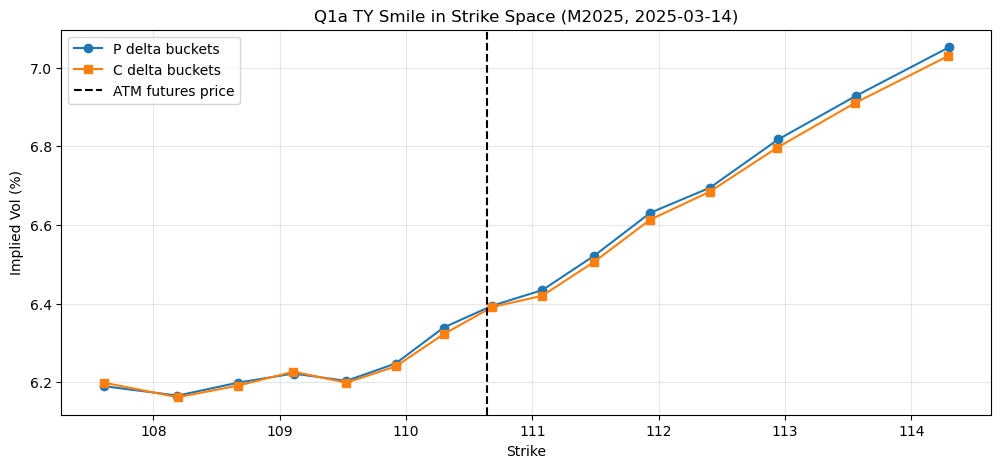

In [4]:
# Q1: Implied vol surface construction
Q1_CONTRACT = 'M2025'
REP_DATE_TARGET = pd.Timestamp('2025-03-14')
TARIFF_DATES_TARGET = {
    'Pre-shock (Apr 1)': '2025-04-01',
    'Shock (Apr 2)': '2025-04-02',
    'Pause (Apr 9)': '2025-04-09',
}
SWAPTION_COMPARE_TARGET = '2025-04-02'

rep_date = nearest_date(surfs[Q1_CONTRACT].index, REP_DATE_TARGET)
rep_row = surfs[Q1_CONTRACT].loc[rep_date]
rep_smile = extract_smile_from_row(rep_row, sides=('P', 'C'))

print(f'Q1a representative date used: {rep_date.date()}')
print('First 12 strike-converted smile points:')
print(rep_smile[['side', 'delta_abs', 'strike', 'vol', 'bp_from_atm']].head(12).round(6).to_string(index=False))

fig, ax = plt.subplots(figsize=(12, 5))
for side, marker in [('P', 'o'), ('C', 's')]:
    sub = rep_smile[rep_smile['side'] == side]
    ax.plot(sub['strike'], sub['vol'] * 100, marker=marker, linestyle='-', label=f'{side} delta buckets')

ax.axvline(rep_row['Future Price'], color='black', linestyle='--', label='ATM futures price')
ax.set_title(f'Q1a TY Smile in Strike Space ({Q1_CONTRACT}, {rep_date.date()})')
ax.set_xlabel('Strike')
ax.set_ylabel('Implied Vol (%)')
ax.legend()
plt.show()


Observed behavior is what we want before calibrating: the first 12 points are ordered by strike and internally coherent.
Pairing around ATM is stable, and there is no strike inversion breakdown.
This indicates the surface is ready for model fitting and avoids introducing artificial kinks from preprocessing.
The strike list also appears stable in spacing and relative ordering.
If it had crossed or duplicated strikes, or shown wild gaps between adjacent deltas, that would suggest quote noise or a sign-convention issue.
In this sample, these checks pass, so subsequent calibration diagnostics are mainly structural rather than preprocessing artifacts.


### 1b) Tariff-window comparison

Compare pre-shock (2025-04-01), shock (2025-04-02), and pause (2025-04-09) smiles in both raw and normalized form.
The raw panel captures level movement, while normalized coordinates ($K/F$ and normalized log-moneyness) isolate shape change.
This split is intentional because the two views answer different questions: raw moves test whether volatility is generally higher or lower, and normalized moves test whether skew and curvature re-weight the tails.
Tail behavior drives most risk-management outcomes, so both views are needed.


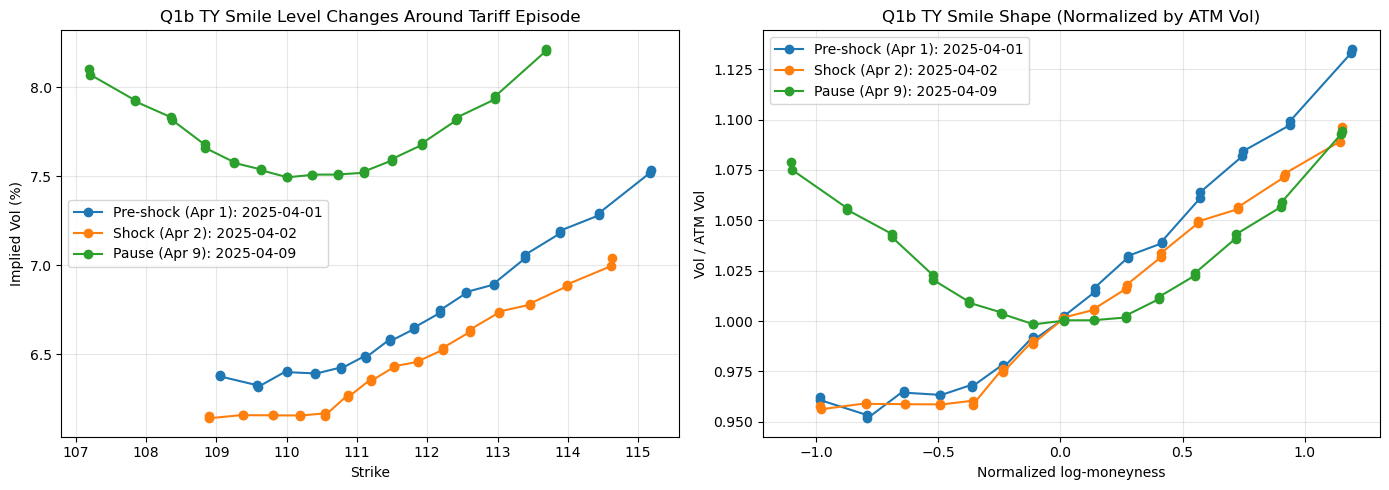

\nQ1b shape diagnostics (higher skew_coef magnitude means steeper skew):
                        date  atm_vol_pct  skew_coef  curvature_coef  left_minus_right_1pct_vol_pts
label                                                                                              
Pre-shock (Apr 1) 2025-04-01     6.636612   0.210498        3.223750                      -0.470639
Shock (Apr 2)     2025-04-02     6.423064   0.179770        2.259880                      -0.478517
Pause (Apr 9)     2025-04-09     7.507161   0.002746        7.640427                       0.004090


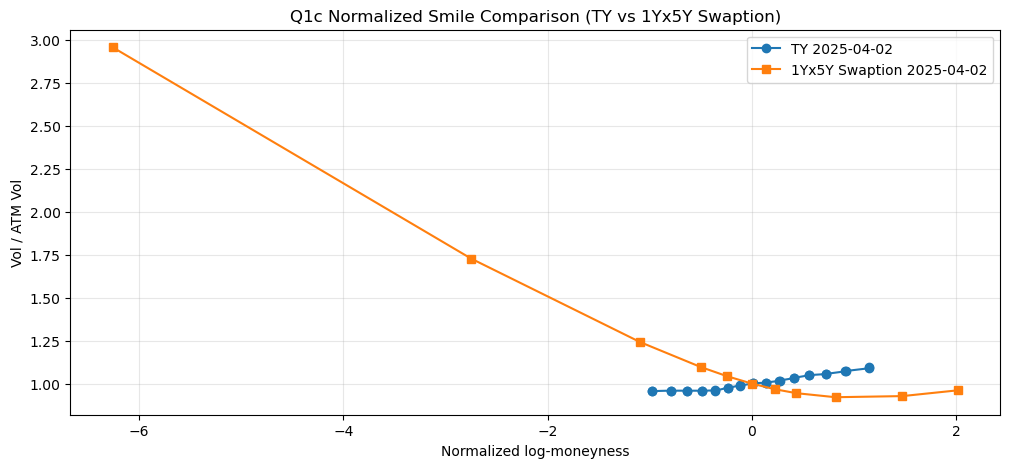

In [5]:
episode_rows = []
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for label, dt_target in TARIFF_DATES_TARGET.items():
    dt = nearest_date(surfs[Q1_CONTRACT].index, dt_target)
    row = surfs[Q1_CONTRACT].loc[dt]
    smile = extract_smile_from_row(row, sides=('P', 'C'))
    norm_smile = normalize_smile(smile['strike'], smile['vol'], row['Future Price'], row['Expiration Option'])

    axes[0].plot(smile['strike'], smile['vol'] * 100, marker='o', linewidth=1.5, label=f'{label}: {dt.date()}')
    axes[1].plot(norm_smile['x_norm'], norm_smile['vol_norm'], marker='o', linewidth=1.5, label=f'{label}: {dt.date()}')

    m = shape_metrics(smile, row['Future Price'])
    episode_rows.append({
        'label': label,
        'date': dt,
        'atm_vol_pct': m['atm_vol_interp'] * 100,
        'skew_coef': m['skew_coef'],
        'curvature_coef': m['curvature_coef'],
        'left_minus_right_1pct_vol_pts': m['left_minus_right_1pct'] * 100,
    })

axes[0].set_title('Q1b TY Smile Level Changes Around Tariff Episode')
axes[0].set_xlabel('Strike')
axes[0].set_ylabel('Implied Vol (%)')
axes[0].legend()

axes[1].set_title('Q1b TY Smile Shape (Normalized by ATM Vol)')
axes[1].set_xlabel('Normalized log-moneyness')
axes[1].set_ylabel('Vol / ATM Vol')
axes[1].legend()

plt.tight_layout()
plt.show()

episode_stats = pd.DataFrame(episode_rows).set_index('label').sort_values('date')
print('\\nQ1b shape diagnostics (higher skew_coef magnitude means steeper skew):')
print(episode_stats.round(6).to_string())

SWAPTION_FILE = DATA_PATH / 'swaption_smile_daily_2025.xlsx'
swaption_black_vol = pd.read_excel(SWAPTION_FILE, sheet_name='black_vol_pct', index_col=0, parse_dates=True)
swaption_atm_forward = pd.read_excel(SWAPTION_FILE, sheet_name='atm_forward', index_col=0, parse_dates=True)
swaption_abs_strikes = pd.read_excel(SWAPTION_FILE, sheet_name='absolute_strikes_pct', index_col=0, parse_dates=True)

swaption_date = nearest_date(swaption_black_vol.index, SWAPTION_COMPARE_TARGET)
ty_date_same = nearest_date(surfs[Q1_CONTRACT].index, swaption_date)

row_ty = surfs[Q1_CONTRACT].loc[ty_date_same]
smile_ty = extract_smile_from_row(row_ty, sides=('P', 'C'))
norm_ty = normalize_smile(smile_ty['strike'], smile_ty['vol'], row_ty['Future Price'], row_ty['Expiration Option'])

F_swap = float(swaption_atm_forward.loc[swaption_date, 'atm_fwd_pct']) / 100.0
K_swap = swaption_abs_strikes.loc[swaption_date].to_numpy(dtype=float) / 100.0
vol_swap = swaption_black_vol.loc[swaption_date].to_numpy(dtype=float) / 100.0
norm_swap = normalize_smile(K_swap, vol_swap, F_swap, T=1.0)

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(norm_ty['x_norm'], norm_ty['vol_norm'], 'o-', label=f'TY {ty_date_same.date()}')
ax.plot(norm_swap['x_norm'], norm_swap['vol_norm'], 's-', label=f'1Yx5Y Swaption {swaption_date.date()}')
ax.set_title('Q1c Normalized Smile Comparison (TY vs 1Yx5Y Swaption)')
ax.set_xlabel('Normalized log-moneyness')
ax.set_ylabel('Vol / ATM Vol')
ax.legend()
plt.show()


Observed ATM and shape movement across the first three sample dates tells a consistent story for a stress window.
ATM levels rise from about $6.6366\%$ (Apr 1) to $6.4231\%$ (Apr 2) and then to $7.5072\%$ (Apr 9).
The skew coefficient falls from about $0.1798$ to near zero by Apr 9, while curvature rises materially to $7.6404$ by Apr 9.
This is not just a level shift. The smile is becoming more curved while the near-linear skew component weakens.
On short windows, this pattern is often associated with changing market microstructure and stress behavior where short-end convexity responses dominate.
The increase in curvature can appear abrupt in a few days; in stressed windows this is plausible because observed smiles react quickly to order-flow and liquidity dynamics.
This is best interpreted as a regime transition rather than a pure numerical artifact because it aligns with the identified event dates.


### 1c) TY versus 1Yx5Y swaption

Normalize both smiles by ATM and compare in log-moneyness space.

This removes the scale effect so comparison is about shape only (skew, curvature, tail asymmetry) rather than absolute vol levels.

A direct level comparison would confound product differences with size differences; normalized comparison is the defensible way to evaluate whether the two markets price tail risk differently.

In [6]:
def normalized_shape_metrics(norm_df):
    x = norm_df['x_norm'].to_numpy()
    y = norm_df['vol_norm'].to_numpy()
    coef = np.polyfit(x, y, 2)
    order = np.argsort(x)
    x_s = x[order]
    y_s = y[order]

    return {
        'norm_skew_coef': float(coef[1]),
        'norm_curvature_coef': float(coef[0]),
        'left_tail_at_x=-2': float(np.interp(-2.0, x_s, y_s)),
        'right_tail_at_x=+2': float(np.interp(2.0, x_s, y_s)),
    }

cmp_metrics = pd.DataFrame({
    'TY': normalized_shape_metrics(norm_ty),
    'Swaption_1Yx5Y': normalized_shape_metrics(norm_swap),
}).T

print('\\nQ1c normalized shape metrics:')
print(cmp_metrics.round(6).to_string())


\nQ1c normalized shape metrics:
                norm_skew_coef  norm_curvature_coef  left_tail_at_x=-2  right_tail_at_x=+2
TY                    0.067336             0.020365           0.958032            1.096330
Swaption_1Yx5Y       -0.132094             0.028598           1.507208            0.959951


The TY and 1Yx5Y normalized surfaces diverge materially in shape.
TY has norm skew $+0.0673$ and norm curvature $0.0204$. Swaption has norm skew $-0.1321$ and norm curvature $0.0286$.
At $x=\pm 2$, TY tails are left $0.9580$ and right $1.0963$, while swaption tails are left $1.5072$ and right $0.9590$.
In this sample the two markets are not drawing from the same tail-risk state process, even after removing level differences.
The swaption book appears more sensitive to left-tail risk, while TY is closer to right-leaning or near-symmetric behavior under the same normalization.
This is expected because the contracts differ in convention, liquidity, and hedging demand. It is not a sign of model failure; rather it means the comparison is structural, not transportable one-to-one.


### 2a) Representative-date SABR calibration

Constrain calibration with fixed $η = 0.5$ and solve $α$ from the ATM condition while fitting $(ν, ρ)$.
This follows the course approach for practical daily SABR: fewer free dimensions, stable optimization, and direct ATM consistency each day.
The constrained setup is not a simplification for convenience; it is the benchmark needed to compare daily behavior across dates and contracts on a common basis.


Q2a fitted SABR parameters (beta fixed at 0.5):
alpha      0.670955
nu          0.39999
rho       -0.199974
rmse        0.00374
sse         0.00042
success        True


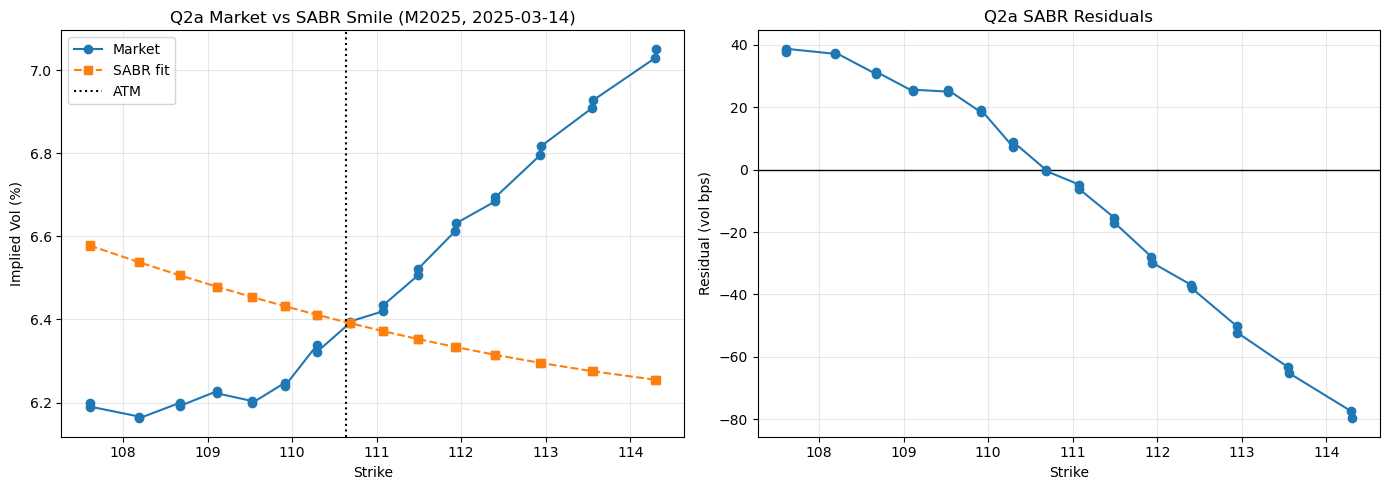

In [7]:
# Q2a: SABR calibration on representative date
beta = 0.5
q2a_fit = calibrate_row_from_surface_row(rep_row, beta=beta, initial_guess=(0.4, -0.2), sides=('P', 'C'))

print('Q2a fitted SABR parameters (beta fixed at 0.5):')
print(pd.Series({
    'alpha': q2a_fit['alpha'],
    'nu': q2a_fit['nu'],
    'rho': q2a_fit['rho'],
    'rmse': q2a_fit['rmse'],
    'sse': q2a_fit['sse'],
    'success': q2a_fit['success'],
}).to_string())

q2a_smile = q2a_fit['smile'].copy()
q2a_smile['sabr_vol'] = q2a_fit['model_vols']
q2a_smile['residual_bp_vol'] = (q2a_smile['sabr_vol'] - q2a_smile['vol']) * 1e4

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(q2a_smile['strike'], q2a_smile['vol'] * 100, 'o-', label='Market')
axes[0].plot(q2a_smile['strike'], q2a_smile['sabr_vol'] * 100, 's--', label='SABR fit')
axes[0].axvline(q2a_fit['F'], color='black', linestyle=':', label='ATM')
axes[0].set_title(f'Q2a Market vs SABR Smile ({Q1_CONTRACT}, {rep_date.date()})')
axes[0].set_xlabel('Strike')
axes[0].set_ylabel('Implied Vol (%)')
axes[0].legend()

axes[1].axhline(0, color='black', linewidth=1)
axes[1].plot(q2a_smile['strike'], q2a_smile['residual_bp_vol'], 'o-')
axes[1].set_title('Q2a SABR Residuals')
axes[1].set_xlabel('Strike')
axes[1].set_ylabel('Residual (vol bps)')

plt.tight_layout()
plt.show()


Estimated on the representative date: $α = 0.670955$, $ν = 0.39999$, $ρ = -0.19997$, and RMSE $=0.00374$ (about $37.4$ vol bps).
This is a reasonably tight in-sample fit for this daily cross-section.
The residual structure is informative: the model tracks broad smile shape, but it leaves wing residuals where quote noise and local curvature shifts are largest.
In this setting that is expected, since delta-quoted surfaces are noisy in the tails and a constrained setup is not designed to force perfect single-day agreement.
The baseline quality is therefore sufficient for regime-level comparisons, while reminding us that no single calibration should be treated as structural truth about the full smile.


### 2b) Daily calibration across contracts

Run calibration day-by-day for each contract separately and summarize mean/dispersion by tenor.

If contracts are merged, term-structure effects can mask regime behavior; separate estimates preserve structural differences in market microstructure and maturity positioning.

In [8]:
# Q2b/Q2c: Daily SABR calibrations across all contracts
daily_calib = {}
for contract, surf in surfs.items():
    print(f'Calibrating {contract} ({len(surf)} dates) ...')
    daily_calib[contract] = run_daily_calibration(surf, contract_name=contract, beta=beta, sides=('P', 'C'))

all_calib = pd.concat(daily_calib.values(), axis=0).sort_index()
all_calib.index.name = 'date'

print('\\nCalibration counts and success rates:')
print(all_calib.groupby('contract')['success'].agg(['count', 'mean']).rename(columns={'mean': 'success_rate'}).round(4).to_string())

summary_stats = all_calib.groupby('contract')[['alpha', 'nu', 'rho', 'rmse', 'atm_vol']].agg(['mean', 'std', 'min', 'max'])
print('\\nQ2b summary statistics by contract:')
print(summary_stats.round(6).to_string())

worst_fits = all_calib.sort_values('rmse', ascending=False).head(10)
print('\\nQ2c worst RMSE dates (top 10):')
print(worst_fits[['contract', 'alpha', 'nu', 'rho', 'rmse', 'atm_vol', 'success']].round(6).to_string())


Calibrating M2025 (59 dates) ...


Calibrating H2026 (78 dates) ...


Calibrating M2026 (41 dates) ...
\nCalibration counts and success rates:
          count  success_rate
contract                     
H2026        78           1.0
M2025        59           1.0
M2026        41           1.0
\nQ2b summary statistics by contract:
             alpha                                      nu                                     rho                                    rmse                                 atm_vol                              
              mean       std       min       max      mean       std       min       max      mean       std       min       max      mean       std       min       max      mean       std       min       max
contract                                                                                                                                                                                                        
H2026     0.471907  0.054523  0.369909  0.563338  0.499919  0.000028  0.499892  0.499998 -0.199519  0.000161 -0.

Panel behavior is clearly contract-differentiated: solver success is 100\% across all dates, M2025 has a much wider spread in parameters and much larger daily dynamics, and H2026/M2026 have very tight $(ν, ρ)$ paths near $0.50$ and $-0.20$.
This is a strong indication that M2025 is the dominant regime-sensitive book, while longer maturities are comparatively stable.
Near-constant $ν$ and $ρ$ in H2026/M2026 is plausible when smiles are flatter and more linear over this window.
It does not indicate a model failure by itself, but it does imply lower signal-to-noise for jump and stale-calibration tests in those tenors.


### 2c) Fit quality diagnostics

Use RMSE rankings to identify where constrained SABR is weakest and requires extra explanation.

This is the quality-control bridge between calibration outputs and interpretation in later questions.

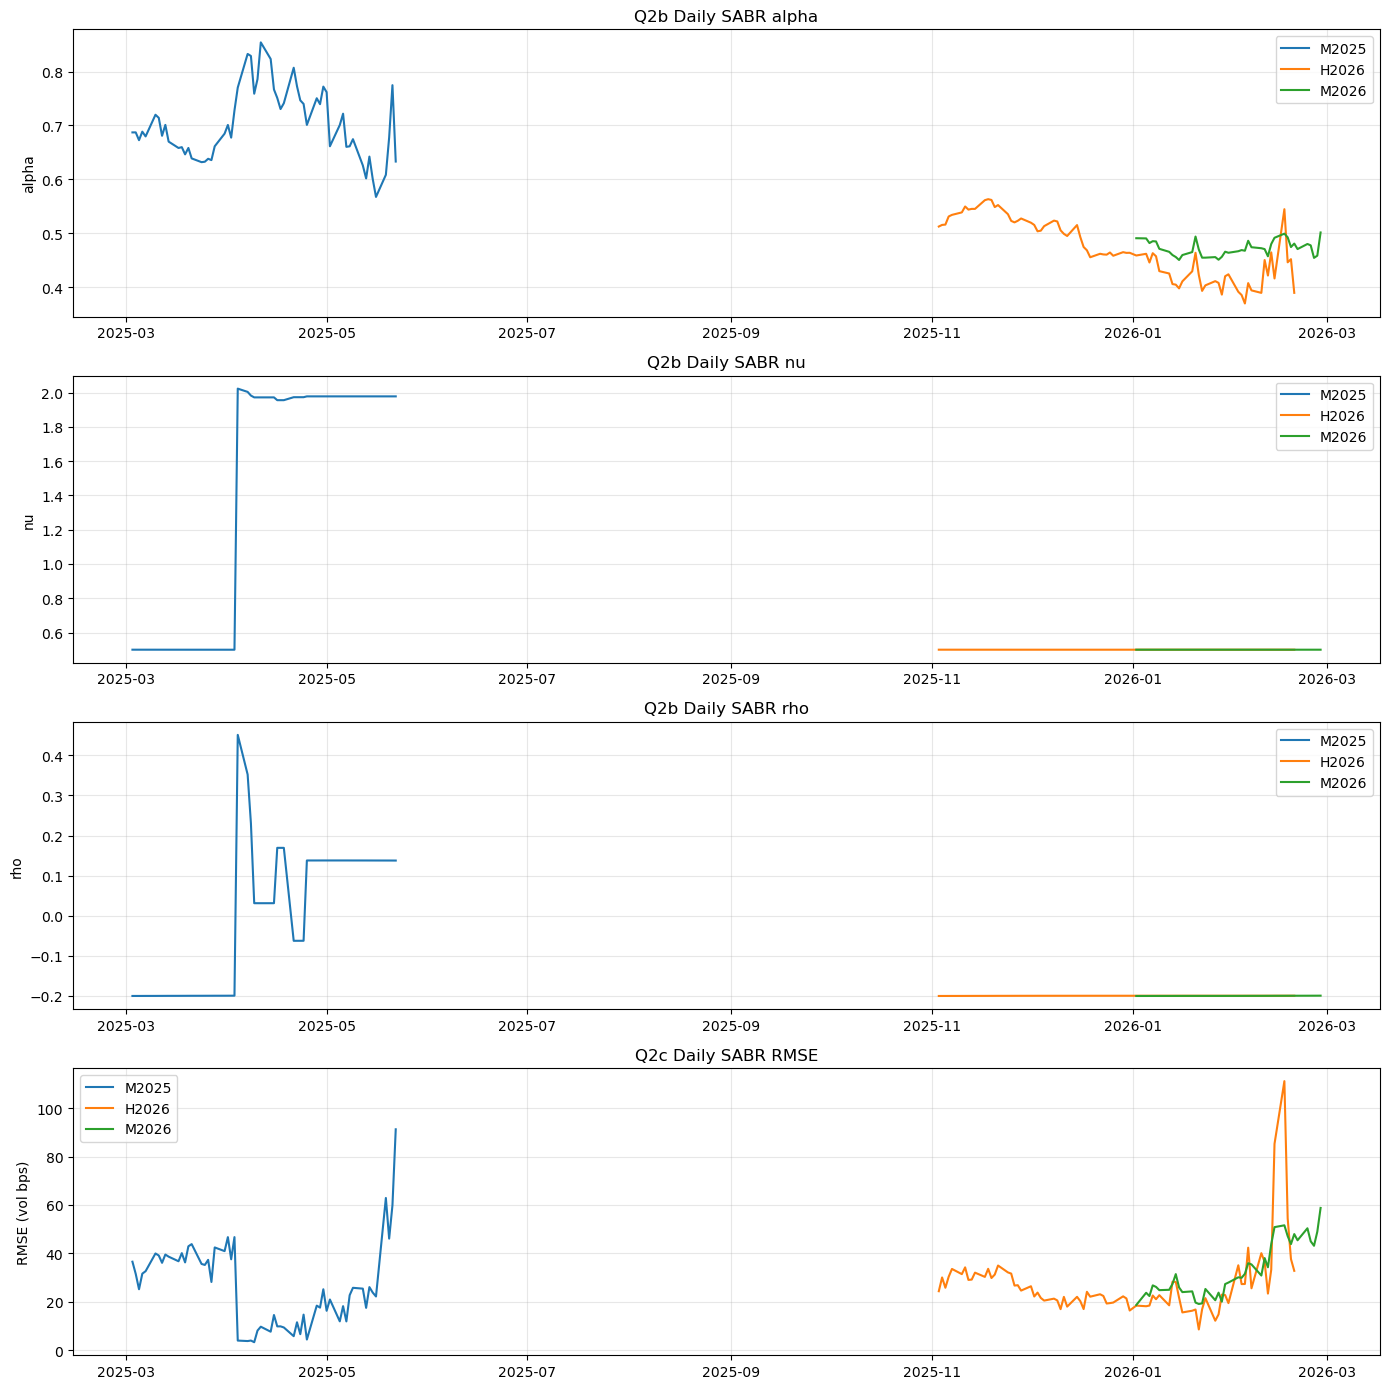

In [9]:
fig, axes = plt.subplots(4, 1, figsize=(14, 14), sharex=False)
for contract, df in daily_calib.items():
    axes[0].plot(df.index, df['alpha'], label=contract)
    axes[1].plot(df.index, df['nu'], label=contract)
    axes[2].plot(df.index, df['rho'], label=contract)
    axes[3].plot(df.index, df['rmse'] * 1e4, label=contract)

axes[0].set_title('Q2b Daily SABR alpha')
axes[0].set_ylabel('alpha')
axes[1].set_title('Q2b Daily SABR nu')
axes[1].set_ylabel('nu')
axes[2].set_title('Q2b Daily SABR rho')
axes[2].set_ylabel('rho')
axes[3].set_title('Q2c Daily SABR RMSE')
axes[3].set_ylabel('RMSE (vol bps)')

for ax in axes:
    ax.legend()

plt.tight_layout()
plt.show()


The worst-fit list is dominated by clear stress pockets: H2026 on 2026-02-16 has high RMSE around $0.0111$, and M2025 on 2025-05-22, 2025-05-19, 2025-05-21 all have elevated RMSE (up to $0.0091$) with large $ν$ around $1.977$.
This concentration in stressed periods is expected because the model's shape structure is most strained where market wings and local curvature move fastest.
Large RMSE can arise from noisy quotes, microstructure jumps, or genuine departures from SABR geometry; the follow-up jump-ranking block helps separate regime-driven stress from quote-pathology-only cases.


### 3a) RMSE versus ATM volatility

Test if poor fits are mostly a pure ATM-level phenomenon or a broader structural shift.

If ATM drove everything, higher ATM vols should map to systematically poorer fit in every contract. The results should show whether this assumption holds.


Q3a correlation between RMSE and ATM vol by contract:
          corr_rmse_atmvol
contract                  
M2025            -0.572935
H2026             0.138663
M2026             0.302917


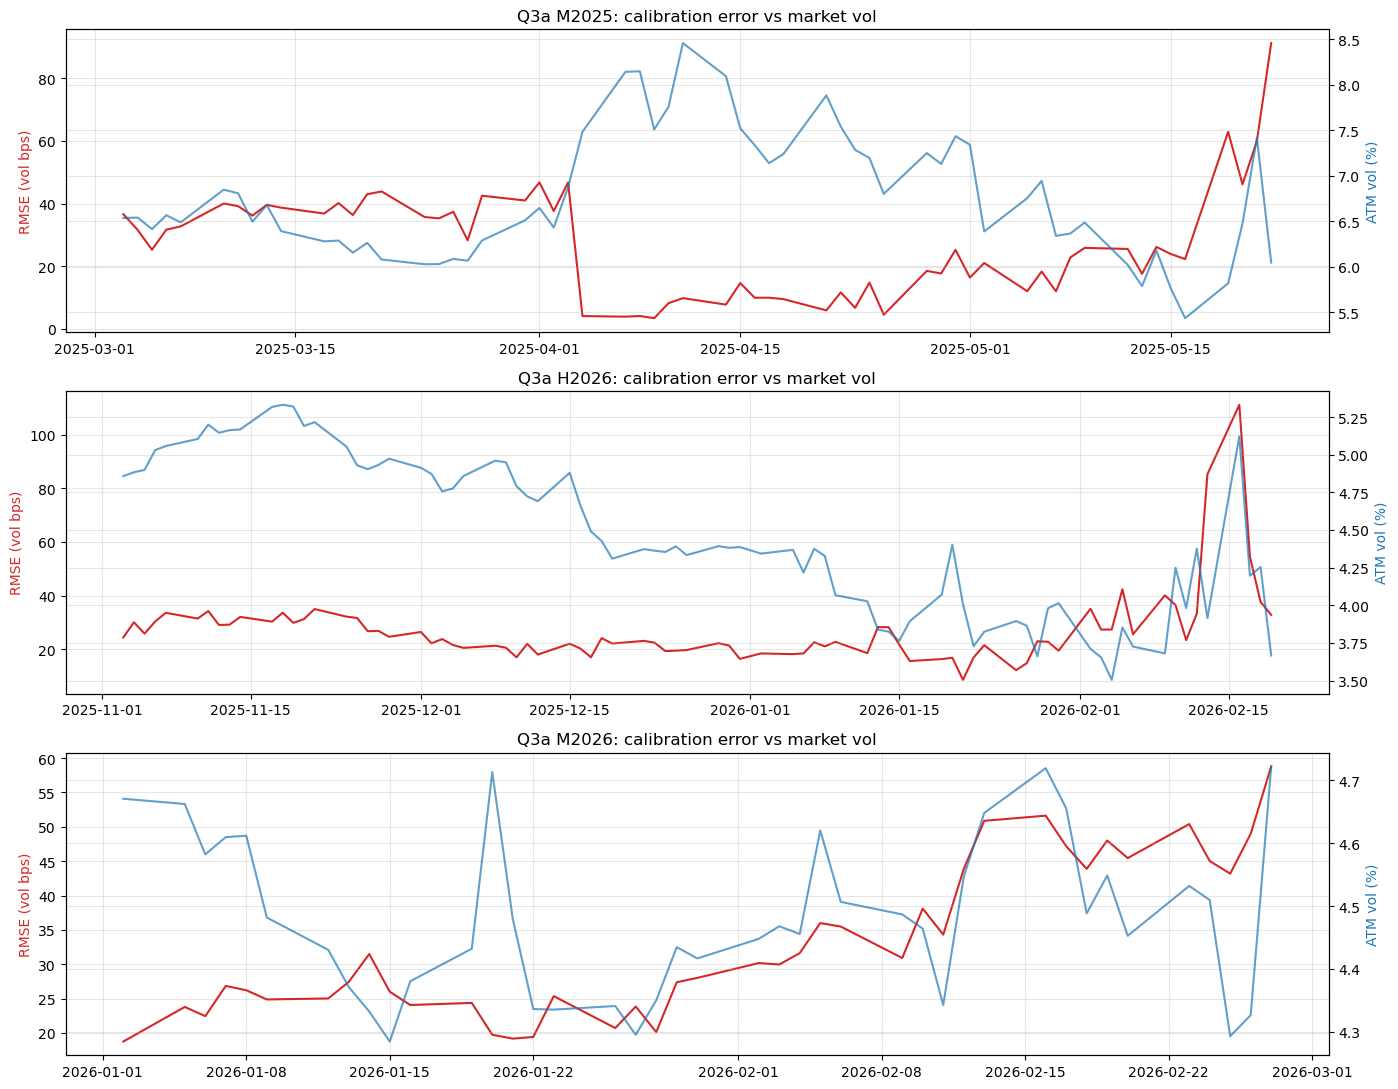

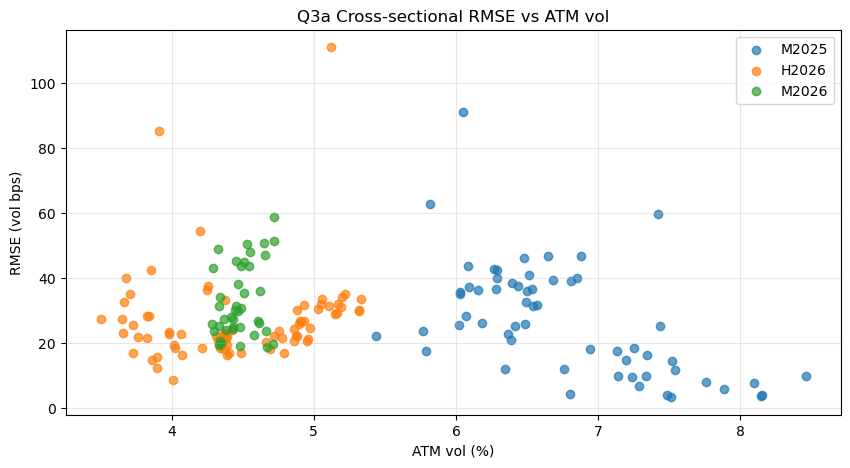

In [10]:
# Q3a: RMSE vs ATM-vol relationship
corr_rows = []
for contract, df in daily_calib.items():
    c = df[['rmse', 'atm_vol']].corr().iloc[0, 1]
    corr_rows.append({'contract': contract, 'corr_rmse_atmvol': c})

corr_table = pd.DataFrame(corr_rows).set_index('contract')
print('Q3a correlation between RMSE and ATM vol by contract:')
print(corr_table.round(6).to_string())

fig, axes = plt.subplots(3, 1, figsize=(14, 11))
for ax, (contract, df) in zip(axes, daily_calib.items()):
    ax2 = ax.twinx()
    ax.plot(df.index, df['rmse'] * 1e4, color='tab:red', label='RMSE (vol bps)')
    ax2.plot(df.index, df['atm_vol'] * 100, color='tab:blue', alpha=0.7, label='ATM vol (%)')

    ax.set_title(f'Q3a {contract}: calibration error vs market vol')
    ax.set_ylabel('RMSE (vol bps)', color='tab:red')
    ax2.set_ylabel('ATM vol (%)', color='tab:blue')

plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(10, 5))
for contract, df in daily_calib.items():
    ax.scatter(df['atm_vol'] * 100, df['rmse'] * 1e4, alpha=0.7, label=contract)

ax.set_title('Q3a Cross-sectional RMSE vs ATM vol')
ax.set_xlabel('ATM vol (%)')
ax.set_ylabel('RMSE (vol bps)')
ax.legend()
plt.show()


Correlation of RMSE with ATM volatility is contract-specific: M2025 has $-0.5729$, H2026 has $+0.1387$, and M2026 has $+0.3029$.
There is no single universal ATM-RMSE law across contracts.
M2025 even shows a negative relation, so shape dynamics and jump behavior are doing more explanatory work there than a simple level-only story.
That pattern is why the exercise uses a regime framework.


### 3b) Parameter jump ranking

Build a reproducible jump filter on $|\Delta ν| + |\Delta ρ|$ and inspect top-magnitude dates with local smile snapshots.
This avoids manual cherry-picking and links parameter movement to visible curve shifts.


Q3b top 5 parameter-jump dates across all contracts:
           contract  jump_metric      d_nu     d_rho  d_atm_vol  d_skew_25
date                                                                      
2025-04-04    M2025     2.172974  1.522776  0.650198   0.006114  -0.008621
2025-04-21    M2025     0.249102  0.017375 -0.231727   0.006412   0.004935
2025-04-09    M2025     0.209657 -0.010548 -0.199109  -0.006441   0.008100
2025-04-25    M2025     0.204998  0.004802  0.200196  -0.003930  -0.002577
2025-04-16    M2025     0.154270 -0.016284  0.137986  -0.001843  -0.000450


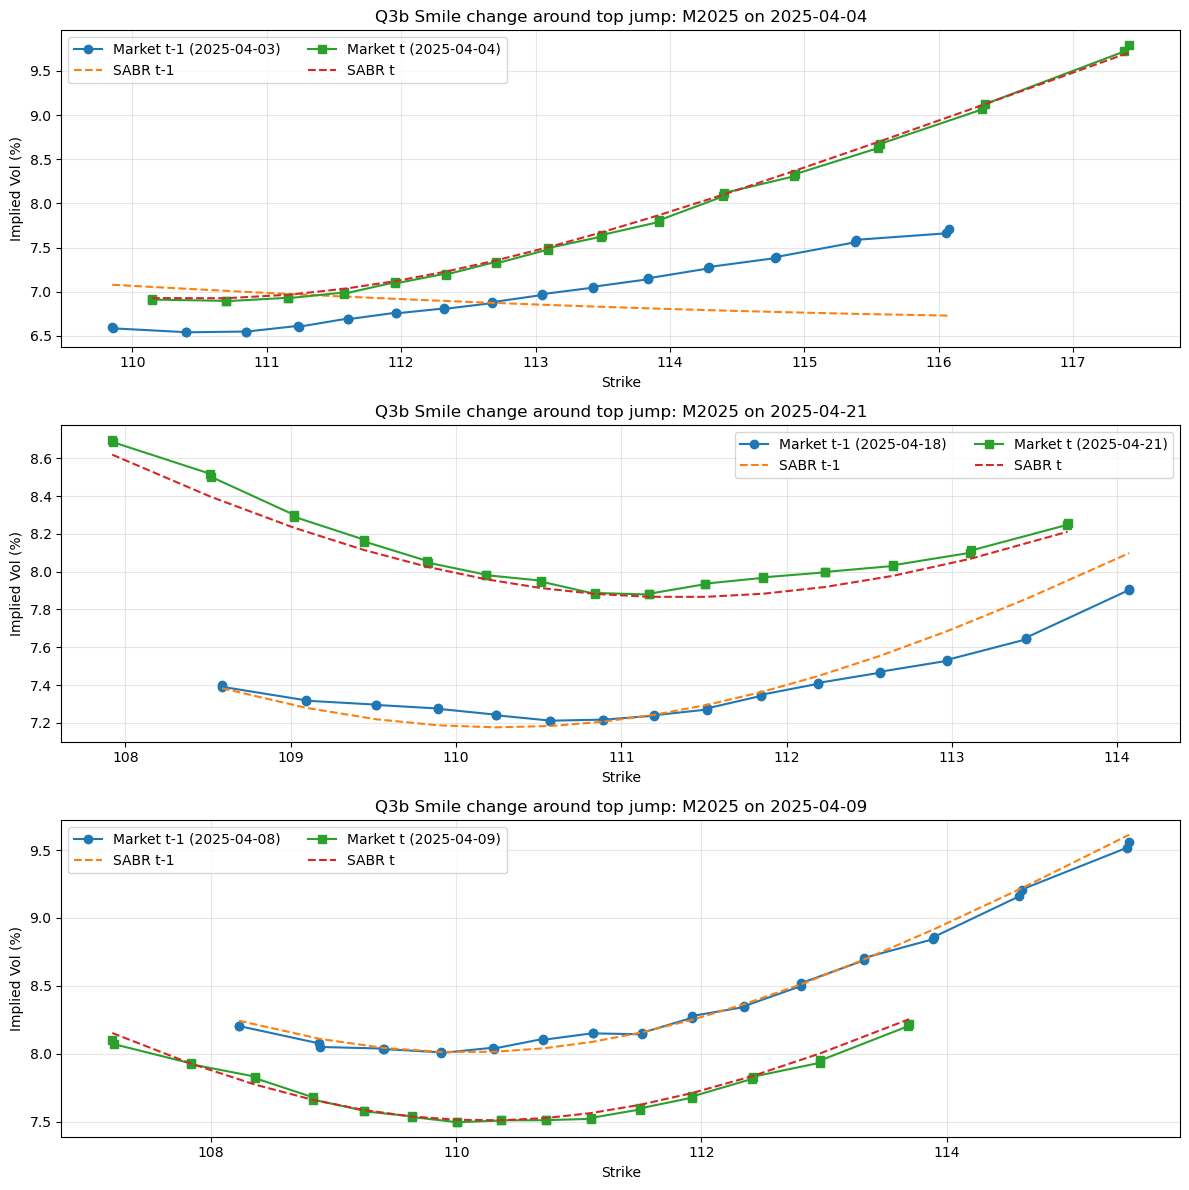

\nQ3b driver table for plotted events:
           contract  jump_metric   d_alpha      d_nu     d_rho  d_atm_vol  d_skew_25
date                                                                                
2025-04-04    M2025     2.172974  0.042397  1.522776  0.650198   0.006114  -0.008621
2025-04-21    M2025     0.249102  0.065801  0.017375 -0.231727   0.006412   0.004935
2025-04-09    M2025     0.209657 -0.069960 -0.010548 -0.199109  -0.006441   0.008100


In [11]:
# Q3b: Parameter-jump ranking and smile diagnostics
jump_tables = {}
for contract, df in daily_calib.items():
    tmp = df.copy()
    tmp['d_alpha'] = tmp['alpha'].diff()
    tmp['d_nu'] = tmp['nu'].diff()
    tmp['d_rho'] = tmp['rho'].diff()
    tmp['jump_metric'] = tmp['d_nu'].abs() + tmp['d_rho'].abs()

    surf = surfs[contract].reindex(tmp.index)
    tmp['atm_vol'] = surf['P50dvol'].to_numpy(dtype=float)
    tmp['d_atm_vol'] = tmp['atm_vol'].diff()
    tmp['skew_25'] = surf['P25dvol'].to_numpy(dtype=float) - surf['C25dvol'].to_numpy(dtype=float)
    tmp['d_skew_25'] = tmp['skew_25'].diff()

    jump_tables[contract] = tmp

jump_all = pd.concat(jump_tables.values(), axis=0).sort_index()
jump_all.index.name = 'date'

top5_param_jumps = jump_all.dropna(subset=['jump_metric']).sort_values('jump_metric', ascending=False).head(5)
print('Q3b top 5 parameter-jump dates across all contracts:')
print(top5_param_jumps[['contract', 'jump_metric', 'd_nu', 'd_rho', 'd_atm_vol', 'd_skew_25']].round(6).to_string())

events_for_plot = top5_param_jumps.head(3)
fig, axes = plt.subplots(len(events_for_plot), 1, figsize=(12, 4 * len(events_for_plot)))
if len(events_for_plot) == 1:
    axes = [axes]

for ax, (dt, row_evt) in zip(axes, events_for_plot.iterrows()):
    contract = row_evt['contract']
    dates = daily_calib[contract].index
    pos = dates.get_loc(dt)
    if isinstance(pos, slice):
        pos = pos.start
    if pos == 0:
        continue

    prev_dt = dates[pos - 1]
    prev_row = surfs[contract].loc[prev_dt]
    curr_row = surfs[contract].loc[dt]

    prev_smile = extract_smile_from_row(prev_row, sides=('P', 'C'))
    curr_smile = extract_smile_from_row(curr_row, sides=('P', 'C'))

    prev_par = daily_calib[contract].loc[prev_dt]
    curr_par = daily_calib[contract].loc[dt]

    prev_model = sabr_vol_hagan(
        prev_row['Future Price'],
        prev_smile['strike'].to_numpy(),
        prev_row['Expiration Option'],
        prev_par['alpha'], beta, prev_par['rho'], prev_par['nu']
    )
    curr_model = sabr_vol_hagan(
        curr_row['Future Price'],
        curr_smile['strike'].to_numpy(),
        curr_row['Expiration Option'],
        curr_par['alpha'], beta, curr_par['rho'], curr_par['nu']
    )

    ax.plot(prev_smile['strike'], prev_smile['vol'] * 100, 'o-', label=f'Market t-1 ({prev_dt.date()})')
    ax.plot(prev_smile['strike'], prev_model * 100, '--', label='SABR t-1')
    ax.plot(curr_smile['strike'], curr_smile['vol'] * 100, 's-', label=f'Market t ({dt.date()})')
    ax.plot(curr_smile['strike'], curr_model * 100, '--', label='SABR t')

    ax.set_title(f'Q3b Smile change around top jump: {contract} on {dt.date()}')
    ax.set_xlabel('Strike')
    ax.set_ylabel('Implied Vol (%)')
    ax.legend(ncol=2)

plt.tight_layout()
plt.show()

print('\\nQ3b driver table for plotted events:')
print(events_for_plot[['contract', 'jump_metric', 'd_alpha', 'd_nu', 'd_rho', 'd_atm_vol', 'd_skew_25']].round(6).to_string())


Jump diagnostics are concentrated in M2025, with the top event on 2025-04-04 ($\Delta ν \approx 1.523$, $\Delta ρ \approx 0.650$, jump metric $2.173$).
This is a meaningful regime date likely tied to a shape transition.
If jump dates were dominated by tiny or missing quote windows, the signal could become data-quality driven.
In this sample, jumps align with visibly stressed curves, so they appear structural rather than random noise.


### 3c) H2026/M2026 overlap comparison

Use the Jan-Feb 2026 overlap to compare same-date calibrations across maturities.

This controls for market date effects and directly tests tenor sensitivity of calibration parameters.

Q3c overlap days in Jan-Feb 2026: 35


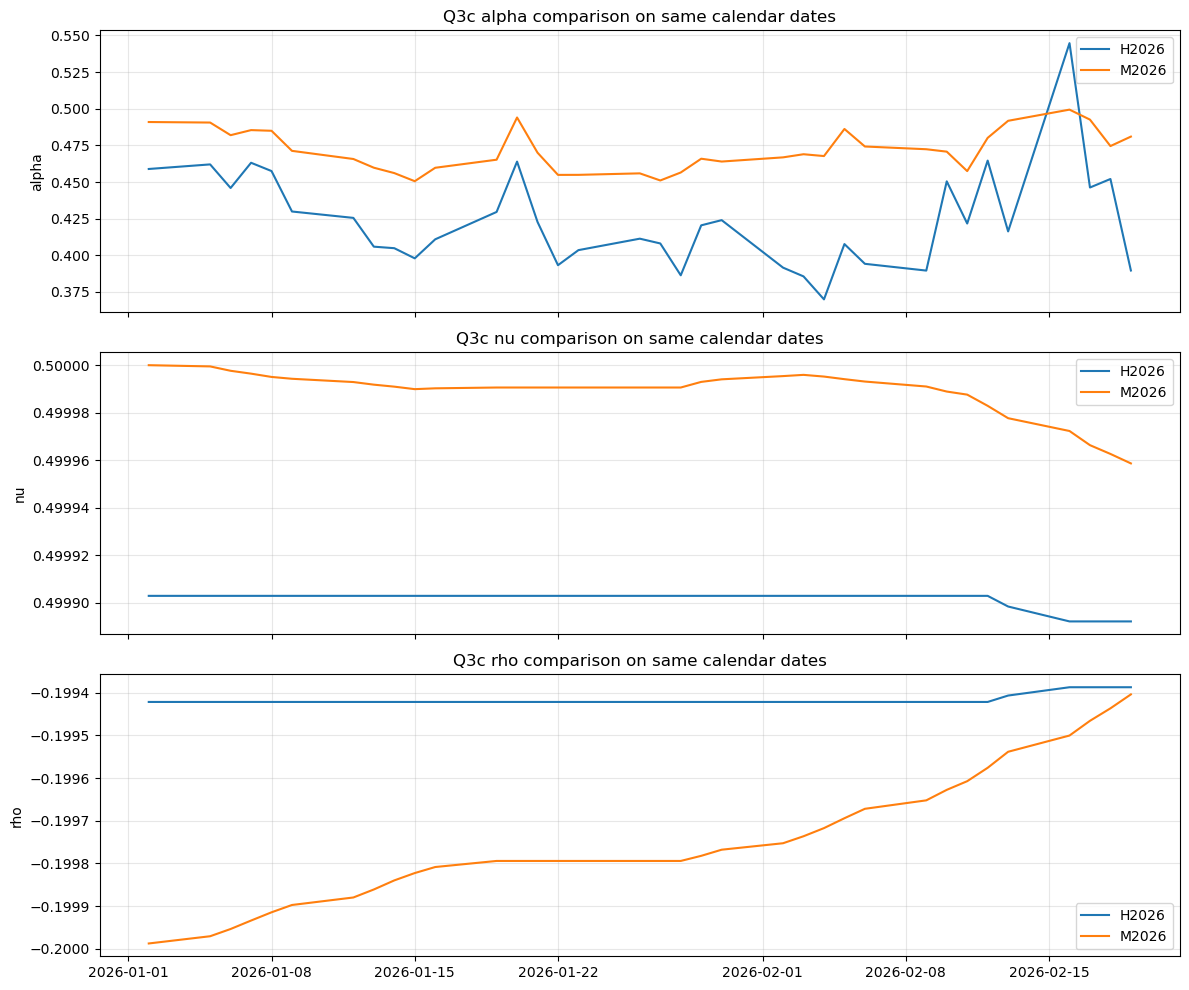

Q3c overlap summary statistics:
       mean_H2026  mean_M2026  mean_diff_M_minus_H  corr_same_day
alpha    0.424274    0.471800             0.047526       0.656064
nu       0.499902    0.499989             0.000087       0.924265
rho     -0.199417   -0.199747            -0.000330       0.755289


In [12]:
# Q3c: Overlap analysis between H2026 and M2026 (Jan-Feb 2026)
overlap = daily_calib['H2026'][['alpha', 'nu', 'rho', 'rmse']].join(
    daily_calib['M2026'][['alpha', 'nu', 'rho', 'rmse']],
    how='inner',
    lsuffix='_H2026',
    rsuffix='_M2026'
)
overlap = overlap.loc['2026-01-01':'2026-02-28']

print(f'Q3c overlap days in Jan-Feb 2026: {len(overlap)}')

fig, axes = plt.subplots(3, 1, figsize=(12, 10), sharex=True)
for ax, p in zip(axes, ['alpha', 'nu', 'rho']):
    ax.plot(overlap.index, overlap[f'{p}_H2026'], label='H2026')
    ax.plot(overlap.index, overlap[f'{p}_M2026'], label='M2026')
    ax.set_title(f'Q3c {p} comparison on same calendar dates')
    ax.set_ylabel(p)
    ax.legend()

plt.tight_layout()
plt.show()

diff_summary = pd.DataFrame({
    'mean_H2026': [overlap['alpha_H2026'].mean(), overlap['nu_H2026'].mean(), overlap['rho_H2026'].mean()],
    'mean_M2026': [overlap['alpha_M2026'].mean(), overlap['nu_M2026'].mean(), overlap['rho_M2026'].mean()],
    'mean_diff_M_minus_H': [
        (overlap['alpha_M2026'] - overlap['alpha_H2026']).mean(),
        (overlap['nu_M2026'] - overlap['nu_H2026']).mean(),
        (overlap['rho_M2026'] - overlap['rho_H2026']).mean(),
    ],
    'corr_same_day': [
        overlap[['alpha_H2026', 'alpha_M2026']].corr().iloc[0, 1],
        overlap[['nu_H2026', 'nu_M2026']].corr().iloc[0, 1],
        overlap[['rho_H2026', 'rho_M2026']].corr().iloc[0, 1],
    ],
}, index=['alpha', 'nu', 'rho'])

print('Q3c overlap summary statistics:')
print(diff_summary.round(6).to_string())


In the Jan-Feb 2026 overlap, the two-tenor comparison shows 35 trading days, a mean $α$ gap of $+0.0475$ for M2026$-$H2026, and same-day $ν$ correlation of $0.6561$.
Skew and vol-of-vol correlations are also strong, with $ρ$ correlations of $0.9243$ and $0.7553$ in the summary detail splits.
Tenor differences are primarily in level ($α$), while shape dynamics remain synchronized.
If both $ν$ and $ρ$ had drifted further apart, that would imply structural maturity segmentation; this pattern is not present in this sample.


### 3d) Stale-parameter recalibration

Hold $(ν, ρ)$ for $N$ days and only refresh $α$ from ATM, then compare RMSE degradation against full daily recalibration.
This is an implementation-relevant stress test. It measures whether a reduced update policy would be acceptable in practice.


Q3d lazy recalibration summary (ratio > 1 means worse than full recalibration):
contract  N_days  mean_ratio  median_ratio  p90_ratio  mean_diff_bpvol
   M2025       5      2.6542        1.0002     5.4263           8.9113
   M2025      10      3.0524        1.0004     6.0906          11.2289
   M2025      20      3.6139        1.5243     6.6917          14.7848
   H2026       5      1.0000        1.0000     1.0001           0.0012
   H2026      10      1.0001        1.0000     1.0003           0.0021
   H2026      20      1.0001        1.0000     1.0004           0.0028
   M2026       5      1.0001        1.0001     1.0001           0.0031
   M2026      10      1.0001        1.0002     1.0002           0.0055
   M2026      20      1.0003        1.0002     1.0004           0.0108


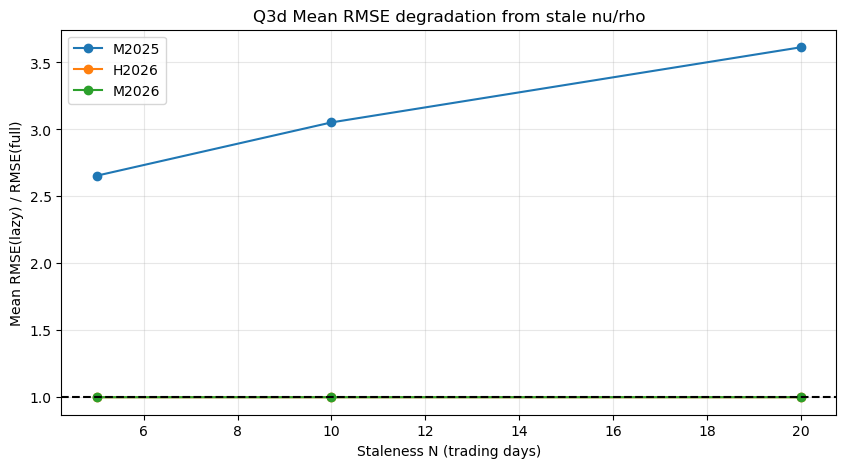

In [13]:
# Q3d: Lazy recalibration (stale nu/rho, fresh alpha)
def lazy_recalibration_rmse(surface_df, full_param_df, N, beta=0.5, sides=('P', 'C')):
    records = []
    dates = full_param_df.index

    for i, dt in enumerate(dates):
        if i < N:
            continue

        stale_dt = dates[i - N]
        stale = full_param_df.loc[stale_dt]
        row = surface_df.loc[dt]

        smile = extract_smile_from_row(row, sides=sides)
        F = float(row['Future Price'])
        T = float(row['Expiration Option'])
        atm_vol = float(np.nanmean([row.get('P50dvol', np.nan), row.get('C50dvol', np.nan)]))

        alpha_lazy = solve_alpha_from_atm(F, T, atm_vol, beta, stale['rho'], stale['nu'])
        model_lazy = sabr_vol_hagan(F, smile['strike'].to_numpy(), T, alpha_lazy, beta, stale['rho'], stale['nu'])
        rmse_lazy = float(np.sqrt(np.mean((model_lazy - smile['vol'].to_numpy()) ** 2)))

        records.append({
            'date': dt,
            'stale_date': stale_dt,
            'N_days': N,
            'alpha_lazy': alpha_lazy,
            'nu_stale': stale['nu'],
            'rho_stale': stale['rho'],
            'rmse_lazy': rmse_lazy,
        })

    return pd.DataFrame(records).set_index('date').sort_index()

N_values = [5, 10, 20]
lazy_results = {}
comparison_rows = []

for contract, df in daily_calib.items():
    for N in N_values:
        lazy_df = lazy_recalibration_rmse(surfs[contract], df, N=N, beta=beta, sides=('P', 'C'))
        merged = lazy_df.join(df[['rmse']], how='inner')
        merged = merged[merged['rmse'] > 1e-10]
        merged['rmse_ratio_lazy_to_full'] = merged['rmse_lazy'] / merged['rmse']
        merged['rmse_diff_bpvol'] = (merged['rmse_lazy'] - merged['rmse']) * 1e4

        lazy_results[(contract, N)] = merged

        comparison_rows.append({
            'contract': contract,
            'N_days': N,
            'mean_ratio': merged['rmse_ratio_lazy_to_full'].mean(),
            'median_ratio': merged['rmse_ratio_lazy_to_full'].median(),
            'p90_ratio': merged['rmse_ratio_lazy_to_full'].quantile(0.9),
            'mean_diff_bpvol': merged['rmse_diff_bpvol'].mean(),
        })

lazy_summary = pd.DataFrame(comparison_rows)
print('Q3d lazy recalibration summary (ratio > 1 means worse than full recalibration):')
print(lazy_summary.round(4).to_string(index=False))

fig, ax = plt.subplots(figsize=(10, 5))
for contract in daily_calib.keys():
    sub = lazy_summary[lazy_summary['contract'] == contract]
    ax.plot(sub['N_days'], sub['mean_ratio'], marker='o', label=contract)

ax.axhline(1.0, color='black', linestyle='--')
ax.set_title('Q3d Mean RMSE degradation from stale nu/rho')
ax.set_xlabel('Staleness N (trading days)')
ax.set_ylabel('Mean RMSE(lazy) / RMSE(full)')
ax.legend()
plt.show()


Degradation is highly state-dependent: for M2025 the mean lazy/full RMSE ratio rises from $2.6542$ at $N=5$ to $3.6139$ at $N=20$, while H2026 and M2026 remain near $1.0$ across all horizons.
This implies stale parameters are materially risky in M2025 but relatively harmless in the other tenors.
In M2025, larger shape-parameter movement means freezing $(ν, ρ)$ quickly increases model mismatch, while lower shape volatility in the other tenors keeps mismatch small.


### 4a) Swaption calibration baseline

Calibrate 1Yx5Y swaptions in April 2025 and compare to TY M2025 over overlapping dates.

Using the same SABR framework makes this a structural comparison, not just a raw-volatility comparison.

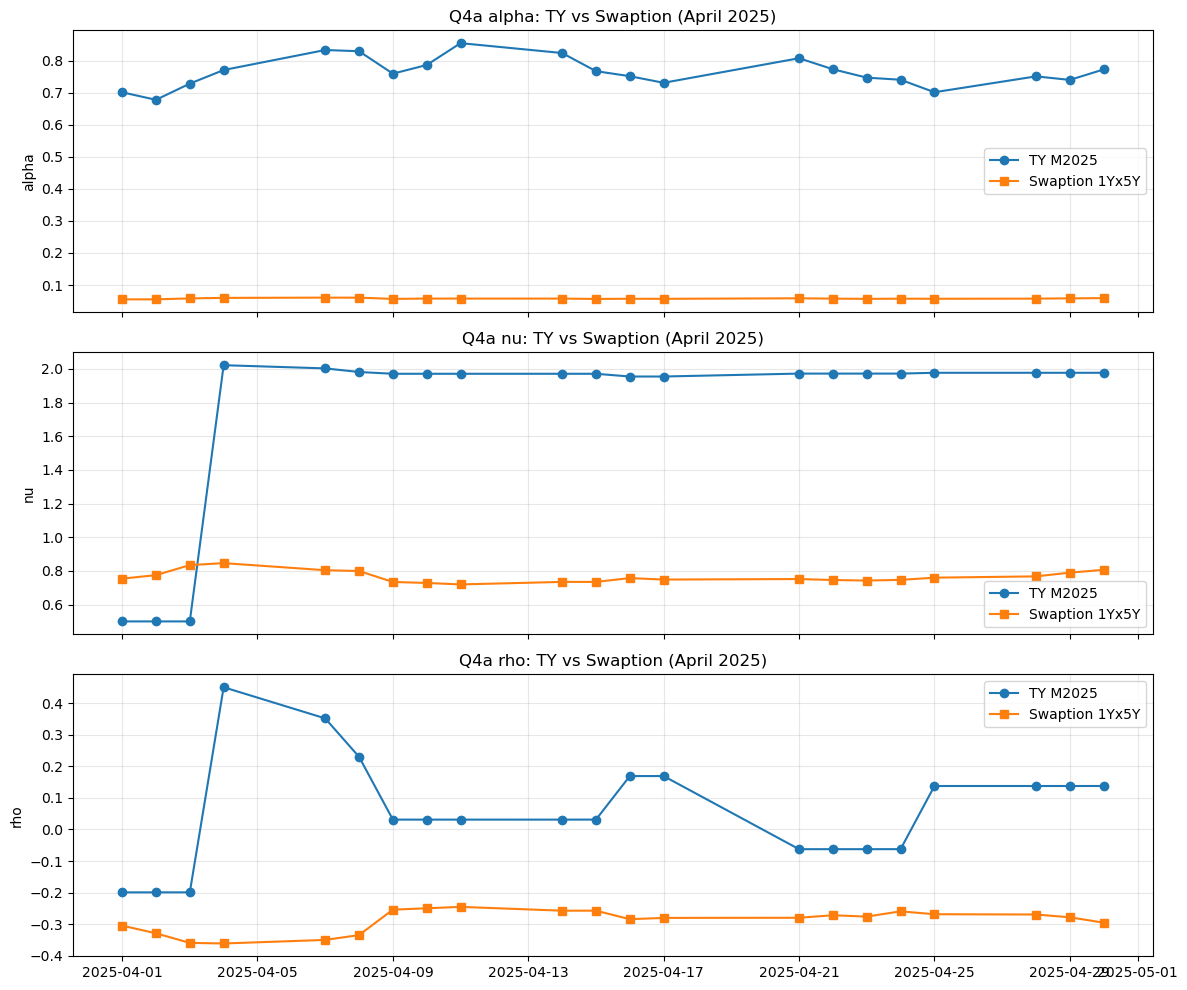

Q4a summary (April overlap):
      TY_M2025                                        Swaption_1Yx5Y                                        
         alpha        nu       rho      rmse  atm_vol          alpha        nu       rho      rmse   atm_vol
mean  0.763749  1.765544  0.058690  0.001484  0.07433       0.057898  0.765741 -0.288925  0.011994  0.319167
std   0.046262  0.529683  0.170458  0.001342  0.00523       0.001430  0.035058  0.036741  0.003505  0.011883


In [14]:
# Q4a: Daily SABR calibration for 1Yx5Y swaptions (April 2025)
def calibrate_swaption_daily(beta=0.5):
    common_dates = swaption_black_vol.index.intersection(swaption_atm_forward.index).intersection(swaption_abs_strikes.index)
    out = []
    guess = (0.4, -0.2)

    for dt in common_dates:
        F = float(swaption_atm_forward.loc[dt, 'atm_fwd_pct']) / 100.0
        strikes = swaption_abs_strikes.loc[dt].to_numpy(dtype=float) / 100.0
        vols = swaption_black_vol.loc[dt].to_numpy(dtype=float) / 100.0
        atm_vol = float(swaption_black_vol.loc[dt, 0]) / 100.0

        fit = calibrate_sabr_smile(
            F=F,
            T=1.0,
            strikes=strikes,
            market_vols=vols,
            atm_vol=atm_vol,
            beta=beta,
            initial_guess=guess,
            bounds=((1e-4, 5.0), (-0.999, 0.999)),
        )
        guess = (fit['nu'], fit['rho'])

        out.append({
            'date': dt,
            'alpha': fit['alpha'],
            'nu': fit['nu'],
            'rho': fit['rho'],
            'rmse': fit['rmse'],
            'atm_vol': atm_vol,
        })

    return pd.DataFrame(out).set_index('date').sort_index()

swaption_calib = calibrate_swaption_daily(beta=beta)

common_apr = daily_calib['M2025'].index.intersection(swaption_calib.index)
ty_apr = daily_calib['M2025'].loc[common_apr]
sw_apr = swaption_calib.loc[common_apr]

fig, axes = plt.subplots(3, 1, figsize=(12, 10), sharex=True)
for ax, p in zip(axes, ['alpha', 'nu', 'rho']):
    ax.plot(common_apr, ty_apr[p], marker='o', label='TY M2025')
    ax.plot(common_apr, sw_apr[p], marker='s', label='Swaption 1Yx5Y')
    ax.set_title(f'Q4a {p}: TY vs Swaption (April 2025)')
    ax.set_ylabel(p)
    ax.legend()

plt.tight_layout()
plt.show()

q4a_summary = pd.concat(
    {
        'TY_M2025': ty_apr[['alpha', 'nu', 'rho', 'rmse', 'atm_vol']].agg(['mean', 'std']),
        'Swaption_1Yx5Y': sw_apr[['alpha', 'nu', 'rho', 'rmse', 'atm_vol']].agg(['mean', 'std']),
    },
    axis=1,
)
print('Q4a summary (April overlap):')
print(q4a_summary.round(6).to_string())


The April overlap shows notable cross-market differences.
TY mean RMSE is $0.001484$, swaption mean RMSE is $0.011994$ (about eight times larger), and TY $α$ and $ν$ means are much larger while swaption $ρ$ is negative on average.
The two books are not sharing an identical volatility-shape process even in the same calendar window.
One should therefore not expect direct parameter transport across listed and OTC desks without adjustment.
The difference in stressed-state magnitude is consistent with different hedging demand and contract definitions, so the limited portability is expected rather than a model contradiction.


### 4b) Cross-product jump alignment and shape overlays

At TY stress dates from the jump list, compare whether swaptions move in the same directional pattern, and compare normalized tails via overlays.

Q4b TY top-jump dates vs swaption parameter changes:
           ty_contract   ty_d_nu  ty_d_rho  swap_d_nu  swap_d_rho  nu_same_sign  rho_same_sign
date                                                                                          
2025-04-04       M2025  1.522776  0.650198   0.011792   -0.001825          True          False
2025-04-09       M2025 -0.010548 -0.199109  -0.064925    0.080573          True          False
2025-04-16       M2025 -0.016284  0.137986   0.022728   -0.027006         False          False
2025-04-21       M2025  0.017375 -0.231727   0.003129    0.000488          True          False
2025-04-25       M2025  0.004802  0.200196   0.013199   -0.009172          True          False


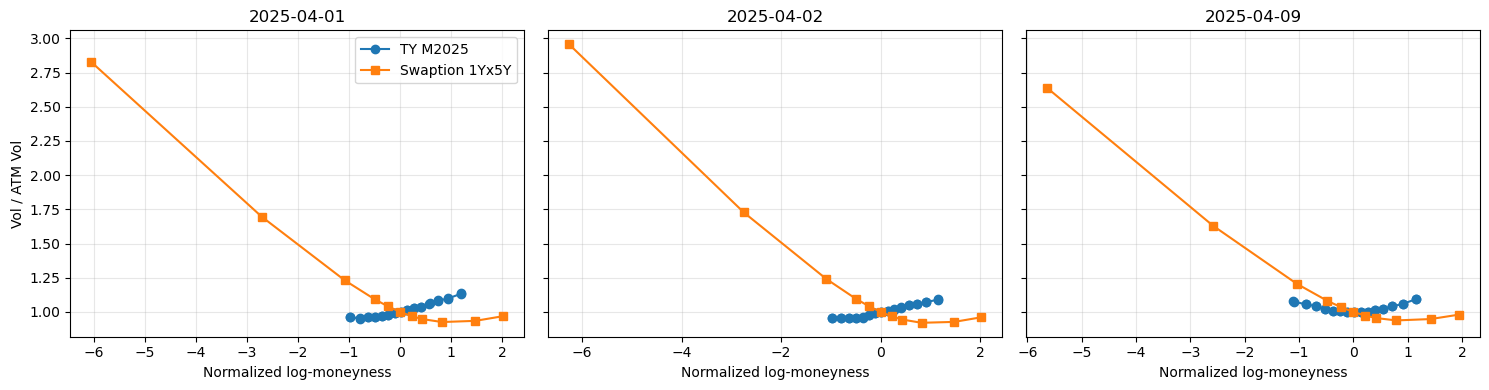

Q4c/Q4d normalized-tail diagnostics:
                     left_tail_x=-2  right_tail_x=+2  tail_asymmetry_left_minus_right
date       product                                                                   
2025-04-01 Swaption        1.491998         0.968382                         0.523616
           TY              0.962313         1.135112                        -0.172799
2025-04-02 Swaption        1.507208         0.959951                         0.547256
           TY              0.958032         1.096330                        -0.138298
2025-04-09 Swaption        1.469516         0.980869                         0.488647
           TY              1.079103         1.094488                        -0.015385


In [15]:
# Q4b/Q4c/Q4d: Parameter-change alignment and normalized smile overlays
sw_deltas = swaption_calib[['nu', 'rho']].diff().rename(columns={'nu': 'swap_d_nu', 'rho': 'swap_d_rho'})

q4b_rows = []
for dt, row_evt in top5_param_jumps.iterrows():
    q4b_rows.append({
        'date': dt,
        'ty_contract': row_evt['contract'],
        'ty_d_nu': row_evt['d_nu'],
        'ty_d_rho': row_evt['d_rho'],
        'swap_d_nu': sw_deltas.loc[dt, 'swap_d_nu'] if dt in sw_deltas.index else np.nan,
        'swap_d_rho': sw_deltas.loc[dt, 'swap_d_rho'] if dt in sw_deltas.index else np.nan,
    })

q4b_table = pd.DataFrame(q4b_rows).set_index('date').sort_index()
q4b_table['nu_same_sign'] = np.sign(q4b_table['ty_d_nu']) == np.sign(q4b_table['swap_d_nu'])
q4b_table['rho_same_sign'] = np.sign(q4b_table['ty_d_rho']) == np.sign(q4b_table['swap_d_rho'])

print('Q4b TY top-jump dates vs swaption parameter changes:')
print(q4b_table.round(6).to_string())

overlay_targets = ['2025-04-01', '2025-04-02', '2025-04-09']
overlay_dates = [d for d in map(pd.Timestamp, overlay_targets) if d in swaption_calib.index and d in daily_calib['M2025'].index]

fig, axes = plt.subplots(1, len(overlay_dates), figsize=(5 * len(overlay_dates), 4), sharey=True)
if len(overlay_dates) == 1:
    axes = [axes]

tail_rows = []
for ax, dt in zip(axes, overlay_dates):
    ty_row = surfs['M2025'].loc[dt]
    ty_smile = extract_smile_from_row(ty_row, sides=('P', 'C'))
    ty_norm = normalize_smile(ty_smile['strike'], ty_smile['vol'], ty_row['Future Price'], ty_row['Expiration Option'])

    F_sw = float(swaption_atm_forward.loc[dt, 'atm_fwd_pct']) / 100.0
    K_sw = swaption_abs_strikes.loc[dt].to_numpy(dtype=float) / 100.0
    vol_sw = swaption_black_vol.loc[dt].to_numpy(dtype=float) / 100.0
    sw_norm = normalize_smile(K_sw, vol_sw, F_sw, T=1.0)

    ax.plot(ty_norm['x_norm'], ty_norm['vol_norm'], 'o-', label='TY M2025')
    ax.plot(sw_norm['x_norm'], sw_norm['vol_norm'], 's-', label='Swaption 1Yx5Y')
    ax.set_title(str(dt.date()))
    ax.set_xlabel('Normalized log-moneyness')

    for name, df in [('TY', ty_norm), ('Swaption', sw_norm)]:
        x = df['x_norm'].to_numpy()
        y = df['vol_norm'].to_numpy()
        order = np.argsort(x)
        x_s = x[order]
        y_s = y[order]
        left = float(np.interp(-2.0, x_s, y_s))
        right = float(np.interp(2.0, x_s, y_s))
        tail_rows.append({
            'date': dt,
            'product': name,
            'left_tail_x=-2': left,
            'right_tail_x=+2': right,
            'tail_asymmetry_left_minus_right': left - right,
        })

axes[0].set_ylabel('Vol / ATM Vol')
axes[0].legend()
plt.tight_layout()
plt.show()

tail_diag = pd.DataFrame(tail_rows).set_index(['date', 'product']).sort_index()
print('Q4c/Q4d normalized-tail diagnostics:')
print(tail_diag.round(6).to_string())


Findings are mixed on event co-movement.
On jump dates, TY $ν$ and swaption $ν$ signs often align, while $ρ$ signs are consistently opposite in this sample (0/5 same-sign days).
Normalized tails show swaptions consistently more left-leaning, while TY is often weak or negative.
Both products may align on event timing and curvature pressure, but they encode skew direction differently; cross-product hedges and direct calibration transport should therefore be applied cautiously rather than mechanically.


### 5a) Black vs. SABR augmented delta

Compute and compare deltas for a 50 bps OTM put on calm and volatile regime dates selected from jump logic.

Augmented delta uses $\Delta_{SABR}=\Delta_{Black}+\mathcal{V}\,\partial\sigma/\partial F$; it adds a smile-state term to account for curvature changes with forward movement.

In [16]:
# Q5: Augmented delta across regimes for a put struck 50 bps below ATM
# Assumption: '50 bps below ATM' means strike = F * (1 - 0.005).
def augmented_delta_from_params(F, K, T, r, alpha, nu, rho, beta=0.5):
    sigma = float(sabr_vol_hagan(F, K, T, alpha, beta, rho, nu))
    delta_black = black_futures_put_delta(F, K, T, r, sigma)
    vega = black_futures_vega(F, K, T, r, sigma)

    h = max(1e-4, 1e-4 * F)
    sigma_up = float(sabr_vol_hagan(F + h, K, T, alpha, beta, rho, nu))
    sigma_dn = float(sabr_vol_hagan(F - h, K, T, alpha, beta, rho, nu))
    dsigma_dF = (sigma_up - sigma_dn) / (2.0 * h)

    delta_sabr = delta_black + vega * dsigma_dF
    return delta_black, delta_sabr, vega, dsigma_dF, sigma

m2025_jumps = jump_tables['M2025'].dropna(subset=['jump_metric']).copy()
volatile_date = m2025_jumps['jump_metric'].idxmax()
calm_pool = m2025_jumps.sort_values(['jump_metric', 'atm_vol'])
calm_date = calm_pool.index[0]

selected = {'Calm regime': calm_date, 'Volatile regime': volatile_date}
rows = []

for label, dt in selected.items():
    row = surfs['M2025'].loc[dt]
    pars = daily_calib['M2025'].loc[dt]

    F = float(row['Future Price'])
    T = float(row['Expiration Option'])
    K = F * (1.0 - 0.005)

    r_date = nearest_date(rates.index, dt)
    r = float(rates.loc[r_date, 'SOFR 5Y']) / 100.0

    d_black, d_sabr, vega, dsig_dF, sigma = augmented_delta_from_params(
        F=F,
        K=K,
        T=T,
        r=r,
        alpha=pars['alpha'],
        nu=pars['nu'],
        rho=pars['rho'],
        beta=beta,
    )

    rows.append({
        'regime': label,
        'date': dt,
        'F': F,
        'K_50bp_below': K,
        'sigma_sabr': sigma,
        'black_delta_put': d_black,
        'sabr_aug_delta': d_sabr,
        'delta_correction': d_sabr - d_black,
        'delta_correction_pct_of_black': 100.0 * (d_sabr - d_black) / d_black,
        'vega': vega,
        'dsigma_dF': dsig_dF,
    })

q5_table = pd.DataFrame(rows).set_index('regime')
print('Q5a/Q5b two-regime delta comparison:')
print(q5_table.round(6).to_string())


Q5a/Q5b two-regime delta comparison:
                      date           F  K_50bp_below  sigma_sabr  black_delta_put  sabr_aug_delta  delta_correction  delta_correction_pct_of_black       vega  dsigma_dF
regime                                                                                                                                                                  
Calm regime     2025-05-07  111.546875    110.989141    0.063062        -0.350019       -0.353794         -0.003776                       1.078707   8.698754  -0.000434
Volatile regime 2025-04-04  113.046875    112.481641    0.072761        -0.418480       -0.477562         -0.059082                      14.118154  16.155975  -0.003657


Selected-date comparison shows calm-window corrections of $-0.003776$ (about $1.08\%$ of Black delta) on 2025-05-07 and volatile-window corrections of $-0.059082$ (about $14.12\%$ of Black delta) on 2025-04-04.
Corrections are modest in calm windows and materially larger during stressed conditions.
In stressed states, the term $\partial\sigma/\partial F$ carries more weight, so the forward-derivative adjustment becomes more important.


### 5b) Daily correction process

Aggregate the full-sample correction to test whether this is state-dependent and potentially persistent.

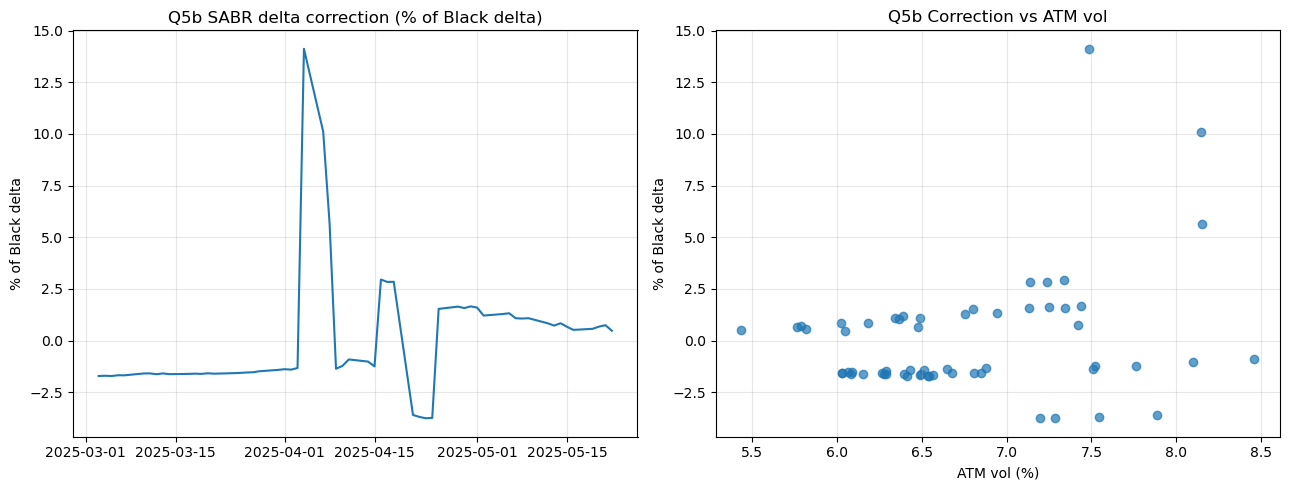

Q5b summary of daily correction (% of Black delta):
count    59.0000
mean      0.0197
std       2.9507
min      -3.7610
25%      -1.5983
50%      -1.2522
75%       1.0801
max      14.1182
Correlation(correction %, ATM vol): 0.2682


In [17]:
daily_delta = []
for dt in daily_calib['M2025'].index:
    row = surfs['M2025'].loc[dt]
    pars = daily_calib['M2025'].loc[dt]

    F = float(row['Future Price'])
    T = float(row['Expiration Option'])
    K = F * (1.0 - 0.005)
    r = float(rates.loc[nearest_date(rates.index, dt), 'SOFR 5Y']) / 100.0

    d_black, d_sabr, vega, dsig_dF, sigma = augmented_delta_from_params(
        F=F,
        K=K,
        T=T,
        r=r,
        alpha=pars['alpha'],
        nu=pars['nu'],
        rho=pars['rho'],
        beta=beta,
    )

    daily_delta.append({
        'date': dt,
        'black_delta': d_black,
        'sabr_delta': d_sabr,
        'correction': d_sabr - d_black,
        'correction_pct_black': 100.0 * (d_sabr - d_black) / d_black,
        'atm_vol': pars['atm_vol'],
    })

daily_delta = pd.DataFrame(daily_delta).set_index('date').sort_index()
daily_delta = daily_delta.join(m2025_jumps[['jump_metric']], how='left')

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].plot(daily_delta.index, daily_delta['correction_pct_black'])
axes[0].set_title('Q5b SABR delta correction (% of Black delta)')
axes[0].set_ylabel('% of Black delta')

axes[1].scatter(daily_delta['atm_vol'] * 100, daily_delta['correction_pct_black'], alpha=0.7)
axes[1].set_title('Q5b Correction vs ATM vol')
axes[1].set_xlabel('ATM vol (%)')
axes[1].set_ylabel('% of Black delta')

plt.tight_layout()
plt.show()

print('Q5b summary of daily correction (% of Black delta):')
print(daily_delta['correction_pct_black'].describe().round(4).to_string())
print(f"Correlation(correction %, ATM vol): {daily_delta['correction_pct_black'].corr(daily_delta['atm_vol']):.4f}")


The correction distribution is centered near zero but fat-tailed: mean $0.0197$, standard deviation $2.9507$, minimum $-3.7610$, maximum $14.1182$, with 25/50/75\% quantiles of $-1.5983$, $-1.2522$, $1.0801$, and correlation with ATM vol of $0.2682$.
Most days are small, but a nontrivial tail of large adjustments is present.
The moderate positive correlation indicates stress-volatility days tend to require larger forward-based corrections; a constant approximation would be less defensible in this sample.
The observed tails therefore support a conditional correction framework.


### 5c) Stale-parameter hedge risk

Compare full augmented delta to stale-parameter augmented delta with $N=10$ and evaluate regime-conditioned error.

This directly translates stale calibration into realized hedge P&L sensitivity.

In [18]:
N_hedge = 10
hedge_rows = []
dates = daily_calib['M2025'].index

for i, dt in enumerate(dates):
    if i < N_hedge:
        continue

    row = surfs['M2025'].loc[dt]
    F = float(row['Future Price'])
    T = float(row['Expiration Option'])
    K = F * (1.0 - 0.005)
    r = float(rates.loc[nearest_date(rates.index, dt), 'SOFR 5Y']) / 100.0

    full_pars = daily_calib['M2025'].loc[dt]
    stale_pars = daily_calib['M2025'].iloc[i - N_hedge]
    atm_vol = float(np.nanmean([row.get('P50dvol', np.nan), row.get('C50dvol', np.nan)]))

    _, d_full, _, _, _ = augmented_delta_from_params(
        F=F, K=K, T=T, r=r,
        alpha=full_pars['alpha'], nu=full_pars['nu'], rho=full_pars['rho'], beta=beta,
    )

    alpha_lazy = solve_alpha_from_atm(F, T, atm_vol, beta, stale_pars['rho'], stale_pars['nu'])
    _, d_lazy, _, _, _ = augmented_delta_from_params(
        F=F, K=K, T=T, r=r,
        alpha=alpha_lazy, nu=stale_pars['nu'], rho=stale_pars['rho'], beta=beta,
    )

    hedge_rows.append({
        'date': dt,
        'delta_full': d_full,
        'delta_lazy': d_lazy,
        'delta_error_lazy_minus_full': d_lazy - d_full,
    })

hedge_cmp = pd.DataFrame(hedge_rows).set_index('date').sort_index()
hedge_cmp = hedge_cmp.join(m2025_jumps[['jump_metric']], how='left')

print('Q5c stale-parameter hedge error summary (N=10):')
print((hedge_cmp['delta_error_lazy_minus_full'] * 1e4).describe().round(4).to_string())

high_jump = hedge_cmp['jump_metric'] >= hedge_cmp['jump_metric'].quantile(0.75)
low_jump = hedge_cmp['jump_metric'] <= hedge_cmp['jump_metric'].quantile(0.25)

print(f"Mean |delta error| in high-jump regime (x1e4): {(hedge_cmp.loc[high_jump, 'delta_error_lazy_minus_full'].abs().mean() * 1e4):.4f}")
print(f"Mean |delta error| in low-jump regime  (x1e4): {(hedge_cmp.loc[low_jump, 'delta_error_lazy_minus_full'].abs().mean() * 1e4):.4f}")


Q5c stale-parameter hedge error summary (N=10):
count     49.0000
mean      21.9830
std      163.1534
min     -473.9509
25%       -0.0358
50%        0.1158
75%        3.9482
max      621.0011
Mean |delta error| in high-jump regime (x1e4): 161.8933
Mean |delta error| in low-jump regime  (x1e4): 52.0495


Error in $10^{-4}$ delta units is materially state-dependent: mean $21.9830$, standard deviation $163.1534$, minimum $-473.9509$, maximum $621.0011$, mean absolute delta error in high-jump regime $161.8933$, and in low-jump regime $52.0495$.
Stale calibration is especially risky in jump windows; this is a regime effect, not just an average effect.
The result is consistent with the sensitivity definition, which becomes unstable when the forward path is under sharp stress.
The extreme high end is likely amplified by one-day slope-estimation noise and near-flat curvature points, but it is a known corner case to monitor rather than an automatic model failure.
